# Spin polarization: LSDA

With `nspin = 2` the density, the potential, the eigenvalues and the wavefunctions all
grow a leading spin axis, and one SCF iteration diagonalises a different Hamiltonian per
channel. What couples them is the exchange-correlation functional, and the Fermi level,
which is **one** number shared by both unless `tot_magnetization` fixes the imbalance.

The density is a pair, and the moment is the integral of its difference:

$$n_\sigma(\mathbf r) = \sum_{n\mathbf k} f_{n\mathbf k\sigma}\,
   |\psi_{n\mathbf k\sigma}(\mathbf r)|^2,
\qquad
m(\mathbf r) = n_\uparrow(\mathbf r) - n_\downarrow(\mathbf r),
\qquad
M = \int m(\mathbf r)\, d\mathbf r$$

The two channels see different potentials,
$v_{xc}^\sigma = \delta E_{xc}[n_\uparrow, n_\downarrow] / \delta n_\sigma$, and that
difference is the whole of band magnetism.

Eight LSDA benchmarks match Quantum ESPRESSO here; nickel's total energy to **2e-9 Ry**
and its moment to the two decimals QE prints.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from pypresso import Calculator
from pypresso.io import read_qe_output
from pypresso.io.pwin import read_pw_input
from pypresso.system.kpoints import KPoints
from pypresso.units import RY_TO_EV

SUITE = Path("../quantum_espresso/qe-7.5-ReleasePack/qe-7.5/test-suite")
REFERENCE, PSEUDO = Path("../tests/data/qe"), Path("../tests/data/pseudo")


def load(directory, name):
    path = SUITE / directory / name
    beta = float(read_pw_input(path).get("electrons", "mixing_beta", 0.7))
    # The input's own mixing_beta becomes this calculator's, so every method
    # that runs an SCF here uses it without being reminded.
    return Calculator.from_file(path, pseudo_dir=PSEUDO, announce=False,
                                conv_thr=1e-10, mixing_beta=beta)


def qe(directory, name):
    # Regenerated with the vendored pw.x: QE's own benchmarks for these cases stop at
    # conv_thr = 1e-6, and their printed terms are only good to about 1e-4 Ry.
    return read_qe_output(REFERENCE / f"reference.out.{directory}-{Path(name).stem}")


# An isolated oxygen atom, whose occupations the input fixes by hand -- the case where
# the two channels differ most.
oxygen = load("pw_atom", "atom-lsda.in").get_scf(max_iterations=200)
ref = qe("pw_atom", "atom-lsda.in")

print("oxygen: converged in %d iterations" % oxygen.iterations)
print("  total energy   %.9f Ry   QE %.8f   difference %.1e"
      % (oxygen.total_energy, ref.total_energy,
         abs(oxygen.total_energy - ref.total_energy)))
print("  magnetization  %.6f mu_B   QE %s" % (oxygen.magnetization, ref.magnetization))
levels = oxygen.eigenvalues_by_spin[:, 0, :] * RY_TO_EV
print("  2s exchange splitting %.4f eV, 2p %.4f eV"
      % (levels[1, 0] - levels[0, 0], levels[1, 1] - levels[0, 1]))

/u/40/ladovj1/data/Documents/programs/claude/pypresso/pypresso/calculator.py:226: UserWarning: K_POINTS gamma asks for the half-sphere storage of the gamma-point trick, which is not implemented; running at an explicit k = 0 with the full G sphere instead. The result is the same, the cost is twice the plane waves
  self._calculation = Calculation(


oxygen: converged in 12 iterations
  total energy   -31.404683565 Ry   QE -31.40468356   difference 4.8e-09
  magnetization  2.000000 mu_B   QE 2.0
  2s exchange splitting 3.2192 eV, 2p 3.0101 eV


## Nickel: the magnetization is an output, not an input

`starting_magnetization` only seeds the first density. What the SCF converges to is
whatever balance of the two channels minimises the energy at one shared Fermi level, and
for fcc nickel that is 0.73 $\mu_B$, a number the calculation produces rather than
reproduces. Nothing forces it to be non-zero: an unpolarized solution exists and is a
stationary point too, just a higher one.

In [2]:
ni = load("pw_lsda", "lsda.in")
nickel = ni.get_scf(max_iterations=200)
ref = qe("pw_lsda", "lsda.in")

print("fcc Ni: %d k-points per channel, converged in %d iterations"
      % (ni.system.kpoints.nk, nickel.iterations))
print("  total energy   %.9f Ry   QE %.8f   difference %.1e"
      % (nickel.total_energy, ref.total_energy,
         abs(nickel.total_energy - ref.total_energy)))
print("  Fermi energy   %.4f eV   QE %.4f eV"
      % (nickel.fermi_energy * RY_TO_EV, ref.fermi_energy))
print("  magnetization  %.4f mu_B   QE %s" % (nickel.magnetization, ref.magnetization))
print("  absolute       %.4f mu_B   QE %s"
      % (nickel.absolute_magnetization, ref.absolute_magnetization))

fcc Ni: 10 k-points per channel, converged in 13 iterations
  total energy   -85.723399012 Ry   QE -85.72339901   difference 1.9e-09
  Fermi energy   15.3088 eV   QE 15.3088 eV
  magnetization  0.7280 mu_B   QE 0.73
  absolute       0.7842 mu_B   QE 0.78


## Where the moment comes from: the exchange splitting

The two channels see different potentials, so the d bands come out at different energies,
rigidly shifted by about 0.7 eV. The majority set is then entirely below $E_F$ and the
minority set is not, and the number of states left over between them is the moment. This
is the Stoner picture, and nickel is its standard illustration.

d-band exchange splitting at Gamma: 0.779 eV


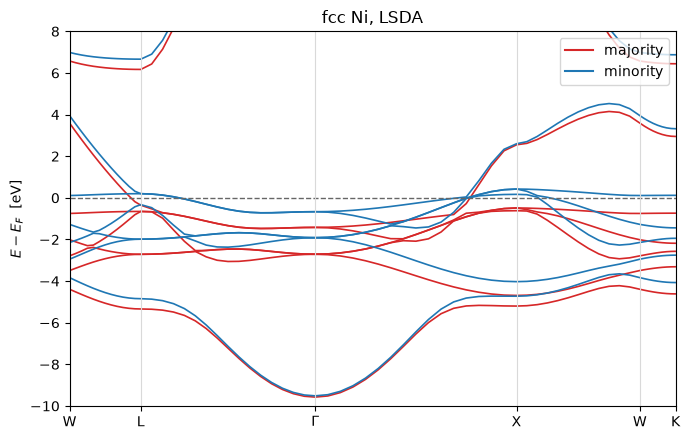

In [3]:
path = np.array([[0.5, 0.25, 0.75], [0.5, 0.5, 0.5], [0.0, 0.0, 0.0],
                 [0.0, 0.0, 1.0], [0.5, 0.25, 0.75], [0.375, 0.375, 0.75]])
counts = np.array([12, 16, 16, 12, 8, 0])
labels = ["W", "L", r"$\Gamma$", "X", "W", "K"]

bands = ni.get_bands(
    kpoints=KPoints.band_path(path, counts, ni.system.cell, crystal=False), nbnd=9)

x = bands.path_length
levels = bands.eigenvalues_by_spin * RY_TO_EV - nickel.fermi_energy * RY_TO_EV
fig, ax = plt.subplots(figsize=(7, 4.5))
for spin, (colour, label) in enumerate((("C3", "majority"), ("C0", "minority"))):
    ax.plot(x, levels[spin], color=colour, lw=1.2)
    ax.plot([], [], color=colour, label=label)
ax.axhline(0.0, color="0.4", ls="--", lw=1)
ticks = [x[i] for i in np.cumsum([0] + list(counts[:-1]))]
for t in ticks:
    ax.axvline(t, color="0.85", lw=0.8)
ax.set_xticks(ticks); ax.set_xticklabels(labels)
ax.set_xlim(x[0], x[-1]); ax.set_ylim(-10, 8)
ax.set_ylabel(r"$E - E_F$  [eV]"); ax.set_title("fcc Ni, LSDA")
ax.legend(loc="upper right"); fig.tight_layout()

gamma = int(np.argmin(np.linalg.norm(np.asarray(bands.kpoints.coords), axis=1)))
at_gamma = bands.eigenvalues_by_spin[:, gamma, :] * RY_TO_EV
print("d-band exchange splitting at Gamma: %.3f eV"
      % float(np.mean(at_gamma[1, 1:6] - at_gamma[0, 1:6])))

## The same thing as a density of states

Two curves instead of one, plotted back to back. The Fermi level is not per channel: the
count whose root is $E_F$ is the sum over both, so a magnetic metal moves electrons from
one channel to the other until that single number is stationary, and the moment is the
imbalance that produces. The majority d states are full and lie below $E_F$; the minority
d states straddle it, which is also why nickel's Fermi surface is the complicated one.

N_up(E_F) = 5.3175   N_dw(E_F) = 4.6825   total = 10.0000  (10 valence electrons)
m from the DOS  +0.6351 mu_B
m from the SCF  +0.7280 mu_B  (on its own 4x4x4 grid)


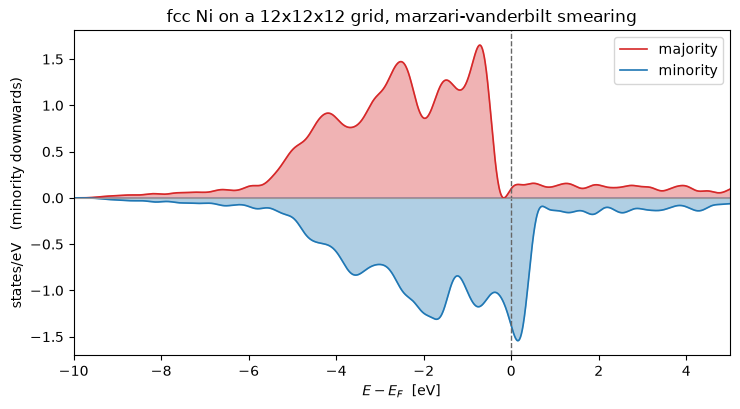

In [4]:
dos = ni.get_dos(grid=(12, 12, 12))
ef = dos.fermi_energy
up, down = (float(np.interp(ef, dos.energies, dos.integrated[s])) for s in range(2))

fig, ax = plt.subplots(figsize=(7.5, 4.2))
energies = (dos.energies - ef) * RY_TO_EV
ax.fill_between(energies, dos.dos_ev[0], 0, color="C3", alpha=0.35)
ax.fill_between(energies, -dos.dos_ev[1], 0, color="C0", alpha=0.35)
ax.plot(energies, dos.dos_ev[0], color="C3", lw=1.2, label="majority")
ax.plot(energies, -dos.dos_ev[1], color="C0", lw=1.2, label="minority")
ax.axvline(0.0, color="0.4", ls="--", lw=1); ax.axhline(0.0, color="0.6", lw=0.8)
ax.set_xlim(-10, 5); ax.set_xlabel(r"$E - E_F$  [eV]")
ax.set_ylabel("states/eV   (minority downwards)")
ax.set_title("fcc Ni on a 12x12x12 grid, %s smearing" % dos.scheme)
ax.legend(); fig.tight_layout()

print("N_up(E_F) = %.4f   N_dw(E_F) = %.4f   total = %.4f  (10 valence electrons)"
      % (up, down, up + down))
print("m from the DOS  %+.4f mu_B" % (up - down))
print("m from the SCF  %+.4f mu_B  (on its own 4x4x4 grid)" % nickel.magnetization)

---
The tests behind this notebook: `tests/regression/test_lsda.py`,
`tests/regression/test_isolated_atom.py`.